In [35]:
# IMPORT LIBRARY


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [36]:
# LOAD DAN INSPECT DATASET

df = sns.load_dataset('iris')

print("Shape Dataset :", df.shape)

print("\nTipe Data:")
print(df.dtypes)

print("\n5 Data Pertama:")
print(df.head())

print("\nStatistik Deskriptif:")
print(df.describe().round(3))

Shape Dataset : (150, 5)

Tipe Data:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

5 Data Pertama:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Statistik Deskriptif:
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.35

In [37]:
# STATISTIK DESKRIPTIF LENGKAP

for kolom in df.select_dtypes(include='number').columns:

    print(f"\n=== {kolom.upper()} ===")

    print(f"Mean      : {df[kolom].mean():.3f}")
    print(f"Median    : {df[kolom].median():.3f}")
    print(f"Std Dev   : {df[kolom].std():.3f}")
    print(f"Skewness  : {df[kolom].skew():.3f}")
    print(f"Kurtosis  : {df[kolom].kurt():.3f}")


=== SEPAL_LENGTH ===
Mean      : 5.843
Median    : 5.800
Std Dev   : 0.828
Skewness  : 0.315
Kurtosis  : -0.552

=== SEPAL_WIDTH ===
Mean      : 3.057
Median    : 3.000
Std Dev   : 0.436
Skewness  : 0.319
Kurtosis  : 0.228

=== PETAL_LENGTH ===
Mean      : 3.758
Median    : 4.350
Std Dev   : 1.765
Skewness  : -0.275
Kurtosis  : -1.402

=== PETAL_WIDTH ===
Mean      : 1.199
Median    : 1.300
Std Dev   : 0.762
Skewness  : -0.103
Kurtosis  : -1.341


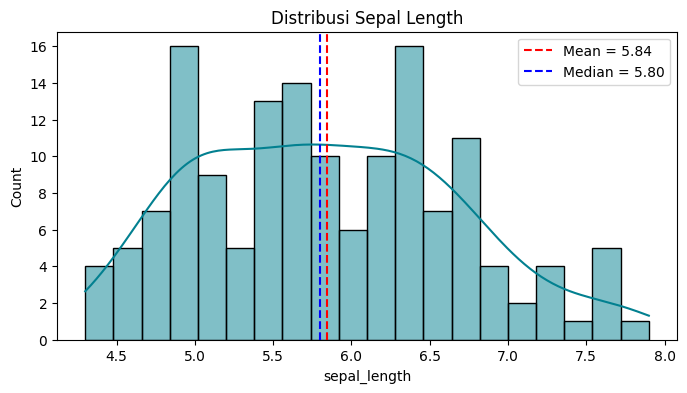

In [38]:
# HISTOGRAM DAN KDE

fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=df,
    x='sepal_length',
    kde=True,
    bins=20,
    color='#028090',
    ax=ax
)

ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

ax.axvline(
    df['sepal_length'].median(),
    color='blue',
    linestyle='--',
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title("Distribusi Sepal Length")
ax.legend()

plt.show()

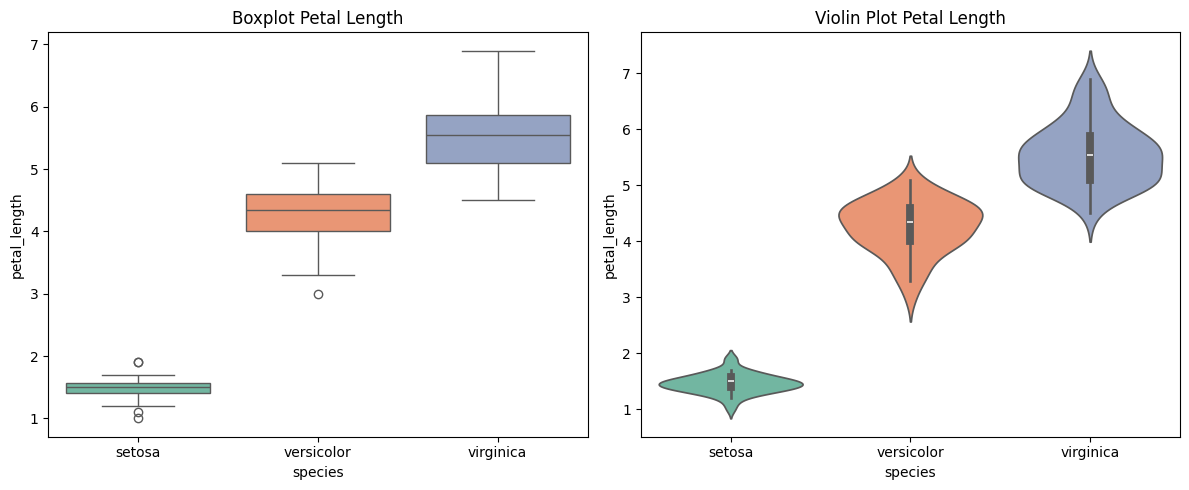

In [39]:
# BOXPLOT DAN VIOLIN PLOT

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Boxplot Petal Length")

sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    legend=False,
    inner='box',
    ax=axes[1]
)

axes[1].set_title("Violin Plot Petal Length")

plt.tight_layout()
plt.show()

In [40]:
# KORELASI PEARSON

corr = df.drop('species', axis=1).corr(method='pearson')

print("Matriks Korelasi:")
print(corr.round(3))

Matriks Korelasi:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


In [41]:
# KORELASI TERTINGGI

mask = np.triu(
    np.ones(corr.shape, dtype=bool)
)

corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()

print(
    f"Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}"
)

Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


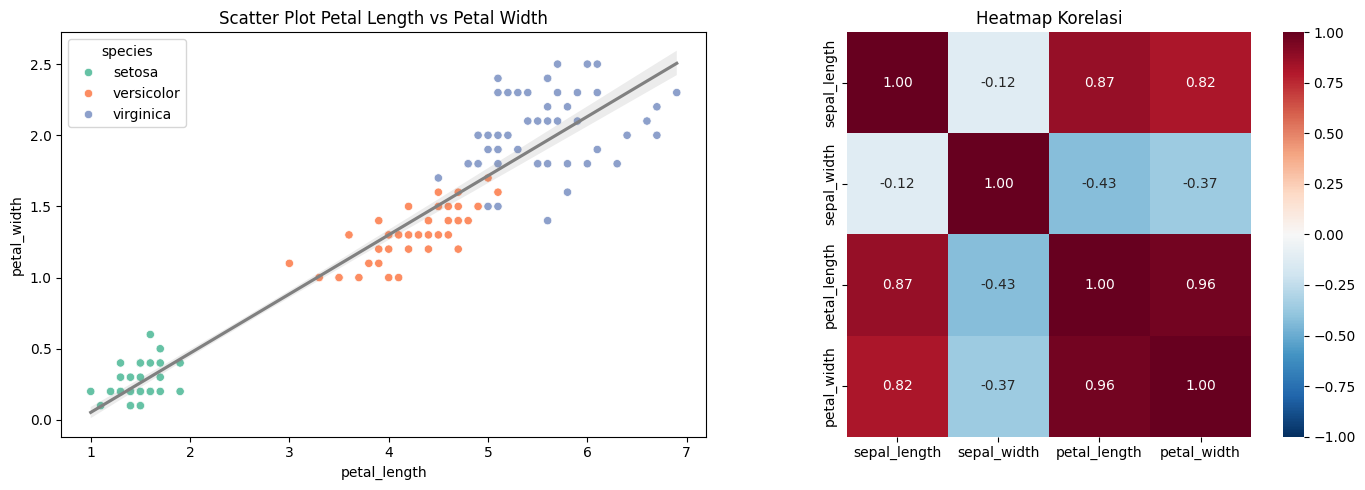

In [42]:
# SCATTER PLOT DAN HEATMAP

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Plot
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title(
    "Scatter Plot Petal Length vs Petal Width"
)

# Heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title("Heatmap Korelasi")

plt.tight_layout()
plt.show()